In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
BASE_DIR=Path(os.getcwd())
FILTERED_DIR=BASE_DIR/"brd4_pipeline"/"data"/"filtered"
PROCESSED_DIR=BASE_DIR/"brd4_pipeline"/"data"/"processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df=pd.read_csv(FILTERED_DIR/"brd4_druglike.csv")
print(f"[INFO] Loaded {len(df):,} drug-like molecules")
print(f"Columns : {df.columns.tolist()}")

[INFO] Loaded 2,210 drug-like molecules
Columns : ['assay_type', 'canonical_smiles', 'data_validity_comment', 'molecule_chembl_id', 'pchembl_value', 'standard_type', 'standard_units', 'standard_value', 'type', 'units', 'value', 'standard_value_nM', 'pIC50', 'smiles_clean', 'is_pains', 'MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotB']


In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

def morgan_fingerprint(smiles, radius=2, nBits=2048):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nBits, dtype=int)
    fp=AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)

    return np.array(fp)
print(f"[INFO] Generating Morgan Fingerprint (ECFP4, 2048 bits)....")
morgan_fps=np.array([morgan_fingerprint(smi) for smi in df['smiles_clean']])

print(f"[DONE] Morgan Fingerprint matrix shape : {morgan_fps.shape}")
print(f" Rows=molecules ({morgan_fps.shape[0]})")
print(f" Columns=bits ({morgan_fps.shape[1]})")
print(f" Example (first 20 bits of molecule 1): {morgan_fps[0,:20]}")

morgan_file=PROCESSED_DIR/"brd4_morgan_fp.npy"
np.save(morgan_file, morgan_fps)
print(f"[SAVED] {morgan_file}")

[INFO] Generating Morgan Fingerprint (ECFP4, 2048 bits)....
[DONE] Morgan Fingerprint matrix shape : (2210, 2048)
 Rows=molecules (2210)
 Columns=bits (2048)
 Example (first 20 bits of molecule 1): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[SAVED] C:\Users\raksh\brd4_pipeline\data\processed\brd4_morgan_fp.npy


In [4]:
from rdkit.Chem import MACCSkeys

In [5]:
def maccs_fingerprint(smiles):
    mol=Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return np.zeros(167, dtype=int)
    fp=MACCSkeys.GenMACCSKeys(mol)
    return np.array(fp)

print(f"[INFO] Generating MACCS Keys fingerprints (167 bits)...")
maccs_fps=np.array([maccs_fingerprint(smi) for smi in df['smiles_clean']])

print(f"[DONE] MACCS fingerprint matrix shape : {maccs_fps.shape}")

maccs_file=PROCESSED_DIR/"brd4_maccs_fp.npy"
np.save(maccs_file, maccs_fps)
print(f"[SAVED] {maccs_file}")

[INFO] Generating MACCS Keys fingerprints (167 bits)...
[DONE] MACCS fingerprint matrix shape : (2210, 167)
[SAVED] C:\Users\raksh\brd4_pipeline\data\processed\brd4_maccs_fp.npy


In [6]:
from rdkit.Chem import RDKFingerprint

In [7]:
def rdkit_fingerprint(smiles, nBits=2048):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nBits, dtype=int)
    fp=RDKFingerprint(mol, fpSize=nBits)
    return np.array(fp)

print("[INFO] Generating RDKit Topological fingerprint (2048 bits),,,")
rdkit_fps=np.array([rdkit_fingerprint(smi) for smi in df['smiles_clean']])

print(f"[DONE] RDKit fingerprint matrix shape : {rdkit_fps.shape}")

rdkit_file=PROCESSED_DIR/"brd4_rdkit_fp.npy"
np.save(rdkit_file, rdkit_fps)
print(f"[SAVED] {rdkit_file}")

[INFO] Generating RDKit Topological fingerprint (2048 bits),,,
[DONE] RDKit fingerprint matrix shape : (2210, 2048)
[SAVED] C:\Users\raksh\brd4_pipeline\data\processed\brd4_rdkit_fp.npy


In [8]:
from rdkit import DataStructs

In [9]:
def tanimoto_similarity(smiles1, smiles2):
    mol1=Chem.MolFromSmiles(str(smiles1))
    mol2=Chem.MolFromSmiles(str(smiles2))
    if mol1 is None or mol2 is None:
        return 0.0
    fp1=AllChem.GetMorganFingerprintAsBitVect(mol1, radius=2, nBits=2048)
    fp2=AllChem.GetMorganFingerprintAsBitVect(mol2, radius=2, nBits=2048)
    return DataStructs.TanimotoSimilarity(fp1, fp2)

df_sorted=df.sort_values('pIC50',ascending=False).reset_index(drop=True)

best_smiles=df_sorted['smiles_clean'].iloc[0]
best_pic50=df_sorted['pIC50'].iloc[0]
best_id=df_sorted['molecule_chembl_id'].iloc[0]

print(f"Reference compound (most potent):")
print(f" ID : {best_id}")
print(f" pIC50 : {best_pic50}")
print(f" SMILES : {str(best_smiles)[:60]}...")

print("[INFO] Calculating Tanimoto similarity to most potent compound..")
df['tanimoto_to_best']=df['smiles_clean'].apply(
    lambda smi: tanimoto_similarity(str(smi), str(best_smiles)))

print(f"\nTanimoto similarity statistics:")
print(df['tanimoto_to_best'].describe().round(3))

very_similar=(df['tanimoto_to_best']>=0.85).sum()
related=((df['tanimoto_to_best']>=0.4) & (df['tanimoto_to_best']<=0.85)).sum()
diverse=(df['tanimoto_to_best']<0.4).sum()

print(f"\nSimilarity bands vs most potent compound:")
print(f" Very similar ( >=0.85) : {very_similar:,} molecules")
print(f" Related (0.4 -0.85) : {related:,} molecules")
print(f" Diverse (<0.40) : {diverse:,} molecules")

Reference compound (most potent):
 ID : CHEMBL3902148
 pIC50 : 10.920818753952377
 SMILES : C[C@H]1NC(=O)c2cc(-c3c(F)ccc4c(=O)n(C)c(NC(C)(C)C)nc34)[nH]c...
[INFO] Calculating Tanimoto similarity to most potent compound..

Tanimoto similarity statistics:
count    2210.000
mean        0.165
std         0.088
min         0.066
25%         0.115
50%         0.143
75%         0.182
max         1.000
Name: tanimoto_to_best, dtype: float64

Similarity bands vs most potent compound:
 Very similar ( >=0.85) : 1 molecules
 Related (0.4 -0.85) : 77 molecules
 Diverse (<0.40) : 2,132 molecules


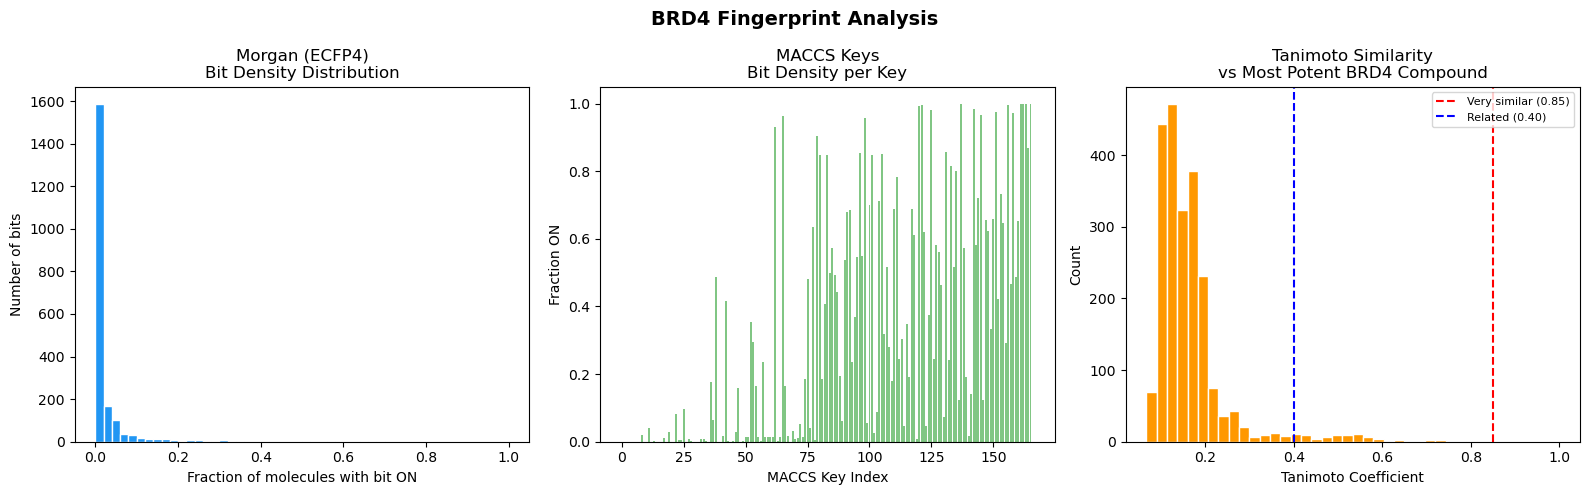

[SAVED] Fingerprint analysis plot saved.


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('BRD4 Fingerprint Analysis', fontsize=14, fontweight='bold')

morgan_density = morgan_fps.mean(axis=0)
axes[0].hist(morgan_density, bins=50, color='#2196F3', edgecolor='white')
axes[0].set_title('Morgan (ECFP4)\nBit Density Distribution')
axes[0].set_xlabel('Fraction of molecules with bit ON')
axes[0].set_ylabel('Number of bits')

maccs_density = maccs_fps.mean(axis=0)
axes[1].bar(range(len(maccs_density)), maccs_density, 
            color='#4CAF50', alpha=0.7)
axes[1].set_title('MACCS Keys\nBit Density per Key')
axes[1].set_xlabel('MACCS Key Index')
axes[1].set_ylabel('Fraction ON')

axes[2].hist(df['tanimoto_to_best'], bins=40, 
             color='#FF9800', edgecolor='white')
axes[2].axvline(x=0.85, color='red', linestyle='--', label='Very similar (0.85)')
axes[2].axvline(x=0.40, color='blue', linestyle='--', label='Related (0.40)')
axes[2].set_title('Tanimoto Similarity\nvs Most Potent BRD4 Compound')
axes[2].set_xlabel('Tanimoto Coefficient')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=8)

plt.tight_layout()

outputs_dir = BASE_DIR / "brd4_pipeline" / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(outputs_dir / "module03_fingerprint_analysis.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] Fingerprint analysis plot saved.")

In [11]:
print("=" * 55)
print("  MODULE 3 — PIPELINE AUDIT REPORT")
print("  Target: BRD4 (CHEMBL4523)")
print("=" * 55)
print(f"  Molecules featurized       : {len(df):,}")
print()
print(f"  Fingerprint matrices saved:")
print(f"    Morgan (ECFP4)  : {morgan_fps.shape}  → brd4_morgan_fp.npy")
print(f"    MACCS Keys      : {maccs_fps.shape} → brd4_maccs_fp.npy")
print(f"    RDKit Topo      : {rdkit_fps.shape}  → brd4_rdkit_fp.npy")
print()
print(f"  Most potent compound       : {best_id}")
print(f"  pIC50                      : {best_pic50:.2f}")
print()
print(f"  Tanimoto vs best compound:")
print(f"    Very similar (≥0.85)     : {very_similar:,}")
print(f"    Related (0.40–0.85)      : {related:,}")
print(f"    Diverse (<0.40)          : {diverse:,}")
print()
print("  Files saved:")
print("  processed/   brd4_morgan_fp.npy")
print("  processed/   brd4_maccs_fp.npy")
print("  processed/   brd4_rdkit_fp.npy")
print("  outputs/     module03_fingerprint_analysis.png")
print("=" * 55)
print("  Module 3 complete.")
print("=" * 55)

  MODULE 3 — PIPELINE AUDIT REPORT
  Target: BRD4 (CHEMBL4523)
  Molecules featurized       : 2,210

  Fingerprint matrices saved:
    Morgan (ECFP4)  : (2210, 2048)  → brd4_morgan_fp.npy
    MACCS Keys      : (2210, 167) → brd4_maccs_fp.npy
    RDKit Topo      : (2210, 2048)  → brd4_rdkit_fp.npy

  Most potent compound       : CHEMBL3902148
  pIC50                      : 10.92

  Tanimoto vs best compound:
    Very similar (≥0.85)     : 1
    Related (0.40–0.85)      : 77
    Diverse (<0.40)          : 2,132

  Files saved:
  processed/   brd4_morgan_fp.npy
  processed/   brd4_maccs_fp.npy
  processed/   brd4_rdkit_fp.npy
  outputs/     module03_fingerprint_analysis.png
  Module 3 complete.
